# 05 — Reportes automáticos

Este notebook define **una función reutilizable** que genera, para cualquier
combinación de UPGD + año + semana, un reporte automático de alerta temprana:
probabilidad de intervención, nivel de riesgo, comparación contra el umbral de
producción (0.12) y los factores explicativos (SHAP) que más pesaron en esa
predicción puntual — con sus gráficos generados dinámicamente.

No es un solo gráfico fijo: la misma celda de reporte se corre varias veces al
final con parámetros distintos (semanas "calientes" vs. semanas tranquilas,
distintas UPGDs) para mostrar que el reporte se adapta a los datos de entrada,
y cada corrida guarda su propia figura en `reports/`.


In [5]:
import sys
from pathlib import Path
from itertools import product
import gc
import json
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap

RAIZ_PROYECTO = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(RAIZ_PROYECTO))

from training.data_loader import cargar_datos
from training.preprocessing import preparar_dengue_base
from training.endemic_channel import calcular_canal_endemico
from training.target import crear_target
from training.feature_engineering import crear_features

AZUL = "#2a78d6"
ROJO = "#e34948"
VERDE = "#0ca30c"
NARANJA = "#eda100"
GRIS_TEXTO = "#52514e"

plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.edgecolor"] = "#c3c2b7"
plt.rcParams["axes.labelcolor"] = GRIS_TEXTO
plt.rcParams["text.color"] = "#0b0b0b"
plt.rcParams["xtick.color"] = GRIS_TEXTO
plt.rcParams["ytick.color"] = GRIS_TEXTO
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.color"] = "#e1e0d9"
plt.rcParams["grid.linewidth"] = 0.6


In [7]:
import sys as _sys
print("Kernel Python en uso:", _sys.executable)
print("RAIZ_PROYECTO detectada:", RAIZ_PROYECTO)

ruta_requerida = RAIZ_PROYECTO / "training"
assert ruta_requerida.exists(), (
    f"⚠️ No se encontró la carpeta de entrenamiento en {ruta_requerida}. "
    f"Verifica que el kernel esté corriendo desde la raíz del proyecto: {RAIZ_PROYECTO}"
)
print("Ruta raíz del proyecto validada correctamente.")

Kernel Python en uso: /home/agustine/Downloads/IA_PREDICTIVA/venv/bin/python
RAIZ_PROYECTO detectada: /home/agustine/Downloads/IA_PREDICTIVA
Ruta raíz del proyecto validada correctamente.


## 1. Reconstrucción del panel + carga del modelo entrenado (mismos artefactos de producción)

In [7]:
df = cargar_datos("03_primary/dataset_limpio.xlsx")
casos_upgd, df_clima, todas_upgds = preparar_dengue_base(df)
todas_semanas = df_clima[["año_ini_sin", "semana_epi_ini_sin"]].drop_duplicates()

esqueleto = pd.DataFrame(
    list(product(todas_semanas.itertuples(index=False), todas_upgds)),
    columns=["semana_combo", "nom_upgd"],
)
esqueleto[["año_ini_sin", "semana_epi_ini_sin"]] = pd.DataFrame(
    esqueleto["semana_combo"].tolist(), index=esqueleto.index
)
esqueleto = esqueleto.drop(columns=["semana_combo"])

panel_maestro = esqueleto.merge(
    casos_upgd, on=["año_ini_sin", "semana_epi_ini_sin", "nom_upgd"], how="left"
)
panel_maestro["casos"] = panel_maestro["casos"].fillna(0).astype(int)
del esqueleto, casos_upgd, df
gc.collect()

panel_maestro = calcular_canal_endemico(panel_maestro)
panel_maestro = crear_target(panel_maestro)
panel_maestro = crear_features(panel_maestro, df_clima)

panel = panel_maestro.dropna(
    subset=["target_intervencion", "casos_lag_52", "media_casos_4"]
).reset_index(drop=True)
panel["target_intervencion"] = panel["target_intervencion"].astype(int)

with open(RAIZ_PROYECTO / "scripts" / "modelo_final_dengue_grave.pkl", "rb") as f:
    modelo = pickle.load(f)
with open(RAIZ_PROYECTO / "scripts" / "metadata_modelo_grave.json", "r") as f:
    metadata = json.load(f)

FEATURES = metadata["features_ordenadas"]
UMBRAL = metadata["umbral_calibrado"]

explainer = shap.TreeExplainer(modelo)

print(f"Modelo cargado. {len(FEATURES)} features, umbral de producción = {UMBRAL}")


Modelo cargado. 142 features, umbral de producción = 0.12


## 2. `generar_reporte_upgd()` — la función de reporte automático

Dado (UPGD, año, semana epidemiológica evaluada), produce:
1. Un resumen en texto (probabilidad, nivel de riesgo, alerta sí/no).
2. Una gráfica de dos paneles: tendencia histórica de casos con la semana
   evaluada resaltada, y los factores SHAP que más empujaron la predicción
   (rojo = aumenta el riesgo, verde = lo atenúa — mismo esquema de color que
   usa el panel de explicabilidad del frontend, para que ambos entregables
   se lean como un solo sistema).
3. Guarda la figura en `reports/reporte_<upgd>_<año>_S<semana>.png`.


In [8]:
def nivel_riesgo(prob):
    pct = prob * 100
    if pct <= 25:
        return "Bajo", VERDE
    elif pct <= 50:
        return "Medio", NARANJA
    elif pct <= 75:
        return "Alto", "#eb6834"
    else:
        return "Crítico", ROJO


def generar_reporte_upgd(nombre_upgd, ano, semana, top_n_factores=6, guardar=True):
    fila = panel[
        (panel["nom_upgd"] == nombre_upgd)
        & (panel["año_ini_sin"] == ano)
        & (panel["semana_epi_ini_sin"] == semana)
    ]
    if fila.empty:
        print(f"⚠️ No hay datos para {nombre_upgd}, año {ano}, semana {semana}.")
        return None

    fila = fila.iloc[[0]]
    X_fila = fila[FEATURES].copy()
    if "nom_upgd" in X_fila.columns:
        X_fila["nom_upgd"] = X_fila["nom_upgd"].astype("category")

    prob = float(modelo.predict_proba(X_fila)[0, 1])
    alerta = prob >= UMBRAL
    nivel, color_nivel = nivel_riesgo(prob)

    print("=" * 72)
    print(f"REPORTE AUTOMÁTICO — {nombre_upgd} — Año {ano}, Semana {semana}")
    print("=" * 72)
    print(f"Probabilidad de intervención (próximas 1-4 semanas): {prob:.1%}")
    print(f"Nivel de riesgo: {nivel}")
    print(f"Umbral de producción: {UMBRAL:.2f}  ->  {'🚨 ALERTA' if alerta else '✅ Sin alerta'}")
    print(f"Casos reportados esa semana: {int(fila['casos'].iloc[0])}")

    # --- Panel 1: tendencia histórica de casos de esa UPGD ---
    historico = panel[panel["nom_upgd"] == nombre_upgd].sort_values(
        ["año_ini_sin", "semana_epi_ini_sin"]
    ).reset_index(drop=True)
    historico["indice_tiempo"] = range(len(historico))
    punto_actual = historico[
        (historico["año_ini_sin"] == ano) & (historico["semana_epi_ini_sin"] == semana)
    ]

    fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

    ax = axes[0]
    ax.plot(historico["indice_tiempo"], historico["casos"], color=AZUL, linewidth=1.4)
    ax.fill_between(historico["indice_tiempo"], historico["casos"], color=AZUL, alpha=0.08)
    if not punto_actual.empty:
        ax.scatter(punto_actual["indice_tiempo"], punto_actual["casos"],
                    color=color_nivel, s=90, zorder=5, edgecolor="white", linewidth=1.2)
    ax.set_title(f"Histórico de casos — {nombre_upgd}", fontsize=11)
    ax.set_xlabel("Semanas (histórico completo)")
    ax.set_ylabel("Casos")
    ax.spines[["top", "right"]].set_visible(False)

    # --- Panel 2: factores SHAP para esta fila puntual ---
    shap_values = explainer.shap_values(X_fila)
    if isinstance(shap_values, list):
        valores = shap_values[1][0]
    elif np.ndim(shap_values) == 3:
        valores = shap_values[0, :, 1]
    else:
        valores = shap_values[0]

    df_shap = pd.DataFrame({"feature": FEATURES, "shap": valores})
    df_shap["abs_shap"] = df_shap["shap"].abs()
    top = df_shap.sort_values("abs_shap", ascending=False).head(top_n_factores).iloc[::-1]
    colores_shap = [ROJO if v > 0 else VERDE for v in top["shap"]]

    ax = axes[1]
    ax.barh(top["feature"], top["shap"], color=colores_shap)
    ax.axvline(0, color="#898781", linewidth=1)
    ax.set_title(f"Top {top_n_factores} factores SHAP — S{semana}/{ano}", fontsize=11)
    ax.set_xlabel("Aporte SHAP (rojo = aumenta riesgo, verde = lo atenúa)")
    ax.spines[["top", "right"]].set_visible(False)

    fig.suptitle(
        f"{nombre_upgd}  ·  {nivel} ({prob:.0%})  ·  {'ALERTA' if alerta else 'sin alerta'}",
        fontsize=13, fontweight="bold", y=1.04,
    )
    plt.tight_layout()

    if guardar:
        carpeta_reportes = RAIZ_PROYECTO / "reports"
        carpeta_reportes.mkdir(exist_ok=True)
        nombre_archivo = f"reporte_{nombre_upgd.replace(' ', '_')}_{ano}_S{semana}.png"
        ruta = carpeta_reportes / nombre_archivo
        fig.savefig(ruta, bbox_inches="tight", dpi=110)
        print(f"📄 Reporte guardado en: {ruta.relative_to(RAIZ_PROYECTO)}")

    plt.show()
    return {"upgd": nombre_upgd, "ano": ano, "semana": semana, "prob": prob, "nivel": nivel, "alerta": alerta}


## 3. Generación dinámica: el mismo reporte, corrido para distintos escenarios

Para demostrar que el reporte es realmente automático (no un gráfico fijo
armado a mano), se identifican de forma dinámica la semana con más casos y una
semana tranquila del histórico, y se corre la función sobre distintas UPGDs sin
tocar el código de arriba.


In [9]:
top_semanas = (
    panel.groupby(["año_ini_sin", "semana_epi_ini_sin"])["casos"].sum()
    .sort_values(ascending=False)
)
semana_alta_ano, semana_alta_num = top_semanas.index[0]

upgds_mas_activas = (
    panel.groupby("nom_upgd")["casos"].sum().sort_values(ascending=False)
)
upgd_1 = upgds_mas_activas.index[0]
upgd_2 = upgds_mas_activas.index[1] if len(upgds_mas_activas) > 1 else upgd_1

print(f"Semana más caliente detectada dinámicamente: {semana_alta_ano} / S{semana_alta_num}")
print(f"UPGDs más activas detectadas dinámicamente: {upgd_1!r}, {upgd_2!r}")


Semana más caliente detectada dinámicamente: 2024 / S37
UPGDs más activas detectadas dinámicamente: 'HOSPITAL LOCAL DEL NORTE', 'CLINICA CHICAMOCHA SA'


REPORTE AUTOMÁTICO — HOSPITAL LOCAL DEL NORTE — Año 2024, Semana 37
Probabilidad de intervención (próximas 1-4 semanas): 98.9%
Nivel de riesgo: Crítico
Umbral de producción: 0.12  ->  🚨 ALERTA
Casos reportados esa semana: 4


/home/agustine/Downloads/IA_PREDICTIVA/venv/lib/python3.14/site-packages/shap/explainers/_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


📄 Reporte guardado en: reports/reporte_HOSPITAL_LOCAL_DEL_NORTE_2024_S37.png


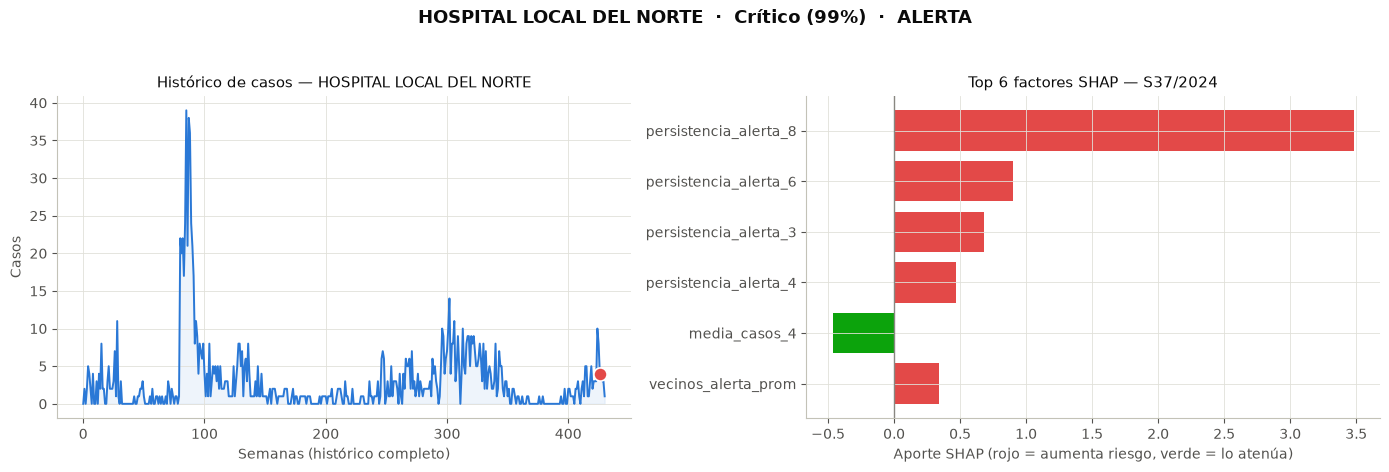

In [10]:
resultados = []
resultados.append(generar_reporte_upgd(upgd_1, semana_alta_ano, semana_alta_num))


REPORTE AUTOMÁTICO — CLINICA CHICAMOCHA SA — Año 2024, Semana 37
Probabilidad de intervención (próximas 1-4 semanas): 98.8%
Nivel de riesgo: Crítico
Umbral de producción: 0.12  ->  🚨 ALERTA
Casos reportados esa semana: 20


/home/agustine/Downloads/IA_PREDICTIVA/venv/lib/python3.14/site-packages/shap/explainers/_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


📄 Reporte guardado en: reports/reporte_CLINICA_CHICAMOCHA_SA_2024_S37.png


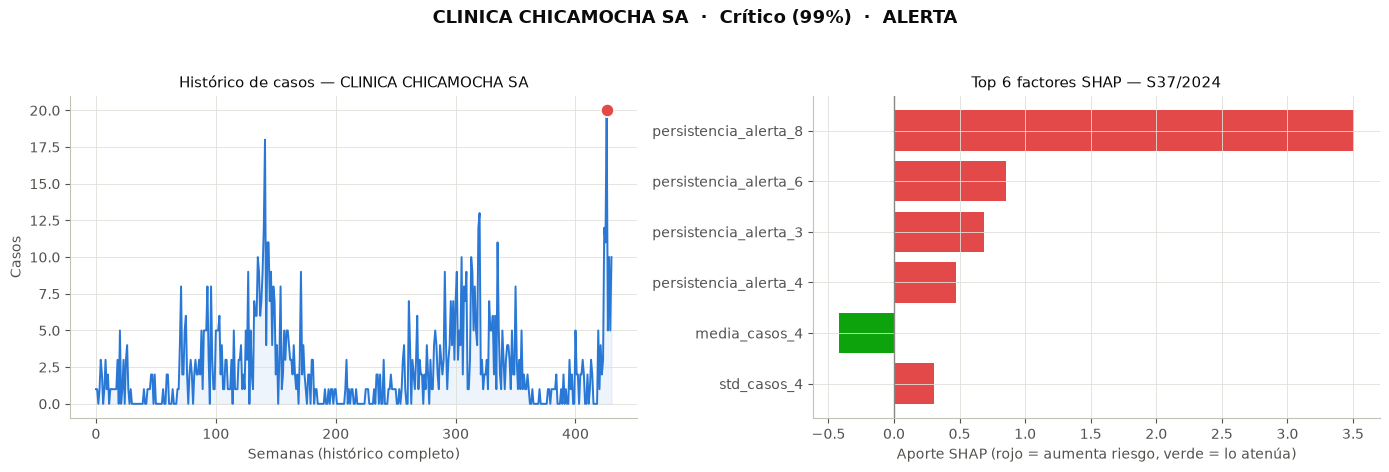

In [11]:
resultados.append(generar_reporte_upgd(upgd_2, semana_alta_ano, semana_alta_num))


REPORTE AUTOMÁTICO — HOSPITAL LOCAL DEL NORTE — Año 2018, Semana 28
Probabilidad de intervención (próximas 1-4 semanas): 96.4%
Nivel de riesgo: Crítico
Umbral de producción: 0.12  ->  🚨 ALERTA
Casos reportados esa semana: 5


/home/agustine/Downloads/IA_PREDICTIVA/venv/lib/python3.14/site-packages/shap/explainers/_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


📄 Reporte guardado en: reports/reporte_HOSPITAL_LOCAL_DEL_NORTE_2018_S28.png


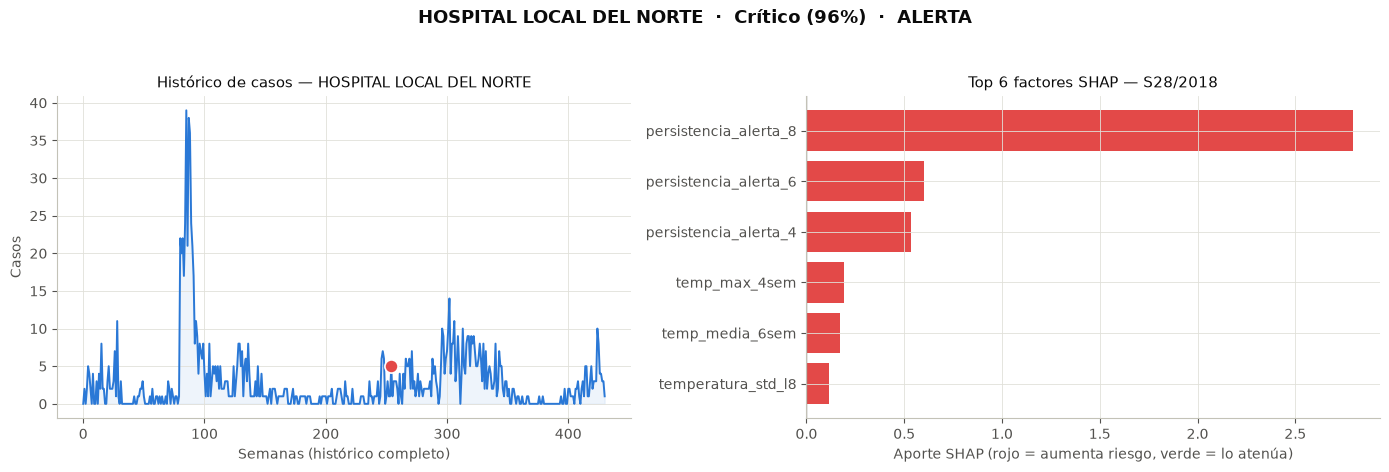

In [12]:
# Escenario adicional: misma UPGD principal, pero en una semana cualquiera de un año distinto,
# para mostrar que el reporte también refleja épocas de bajo riesgo, no solo brotes.
otros_anos = sorted(panel[panel["nom_upgd"] == upgd_1]["año_ini_sin"].unique())
ano_alterno = otros_anos[len(otros_anos)//2]
semanas_ese_ano = sorted(
    panel[(panel["nom_upgd"] == upgd_1) & (panel["año_ini_sin"] == ano_alterno)]["semana_epi_ini_sin"].unique()
)
semana_alterna = semanas_ese_ano[len(semanas_ese_ano)//2]

resultados.append(generar_reporte_upgd(upgd_1, ano_alterno, semana_alterna))


## 4. Resumen tabular de todos los reportes generados en esta corrida

In [13]:
df_resumen = pd.DataFrame([r for r in resultados if r is not None])
df_resumen["prob"] = (df_resumen["prob"] * 100).round(1)
df_resumen = df_resumen.rename(columns={"prob": "prob_%"})
df_resumen


,upgd,ano,semana,prob_%,nivel,alerta
0,HOSPITAL LOCAL DEL NORTE,2024,37,98.9,Crítico,True
1,CLINICA CHICAMOCHA SA,2024,37,98.8,Crítico,True
2,HOSPITAL LOCAL DEL NORTE,2018,28,96.4,Crítico,True


## 5. Conclusión

`generar_reporte_upgd()` es un generador de reportes parametrizable: cualquier
combinación válida de UPGD/año/semana produce automáticamente su probabilidad,
nivel de riesgo, comparación contra el umbral de producción y su propio par de
gráficos (tendencia histórica + factores SHAP), sin necesidad de escribir
código nuevo por cada caso. Los archivos `.png` quedan guardados en
`reports/`, listos para anexar a una presentación o enviar a un equipo de
salud pública sin tener que volver a correr el notebook.
